<a href="https://colab.research.google.com/github/angeruzzi/statistics-studies/blob/main/chatterjee_vs_classical_correlations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# O que observar nos resultados (Análise Técnica):

* **Linear**: Todos os índices devem apresentar valores altos (próximos de 1.0), pois a relação é perfeitamente monotônica e linear.

* **Quadrático (Parábola)**: Aqui você notará que Pearson, Spearman e Kendall caem drasticamente (muitas vezes para próximo de zero), porque a relação não é monotônica (Y desce e depois sobe). No entanto, o ξ de Chatterjee permanecerá alto, pois ele detecta que Y é uma função de X.

* **Senoidal**: Similar ao quadrático, mas com mais inversões de tendência. É o cenário onde o diferencial do Chatterjee é mais evidente em relação aos "clássicos", que ficam "cegos" para a associação funcional oscilatória.

* **Independente**: Todos os índices, incluindo o de Chatterjee, devem convergir para valores próximos de 0, validando a propriedade de que ξ=0 se e somente se houver independência estocástica

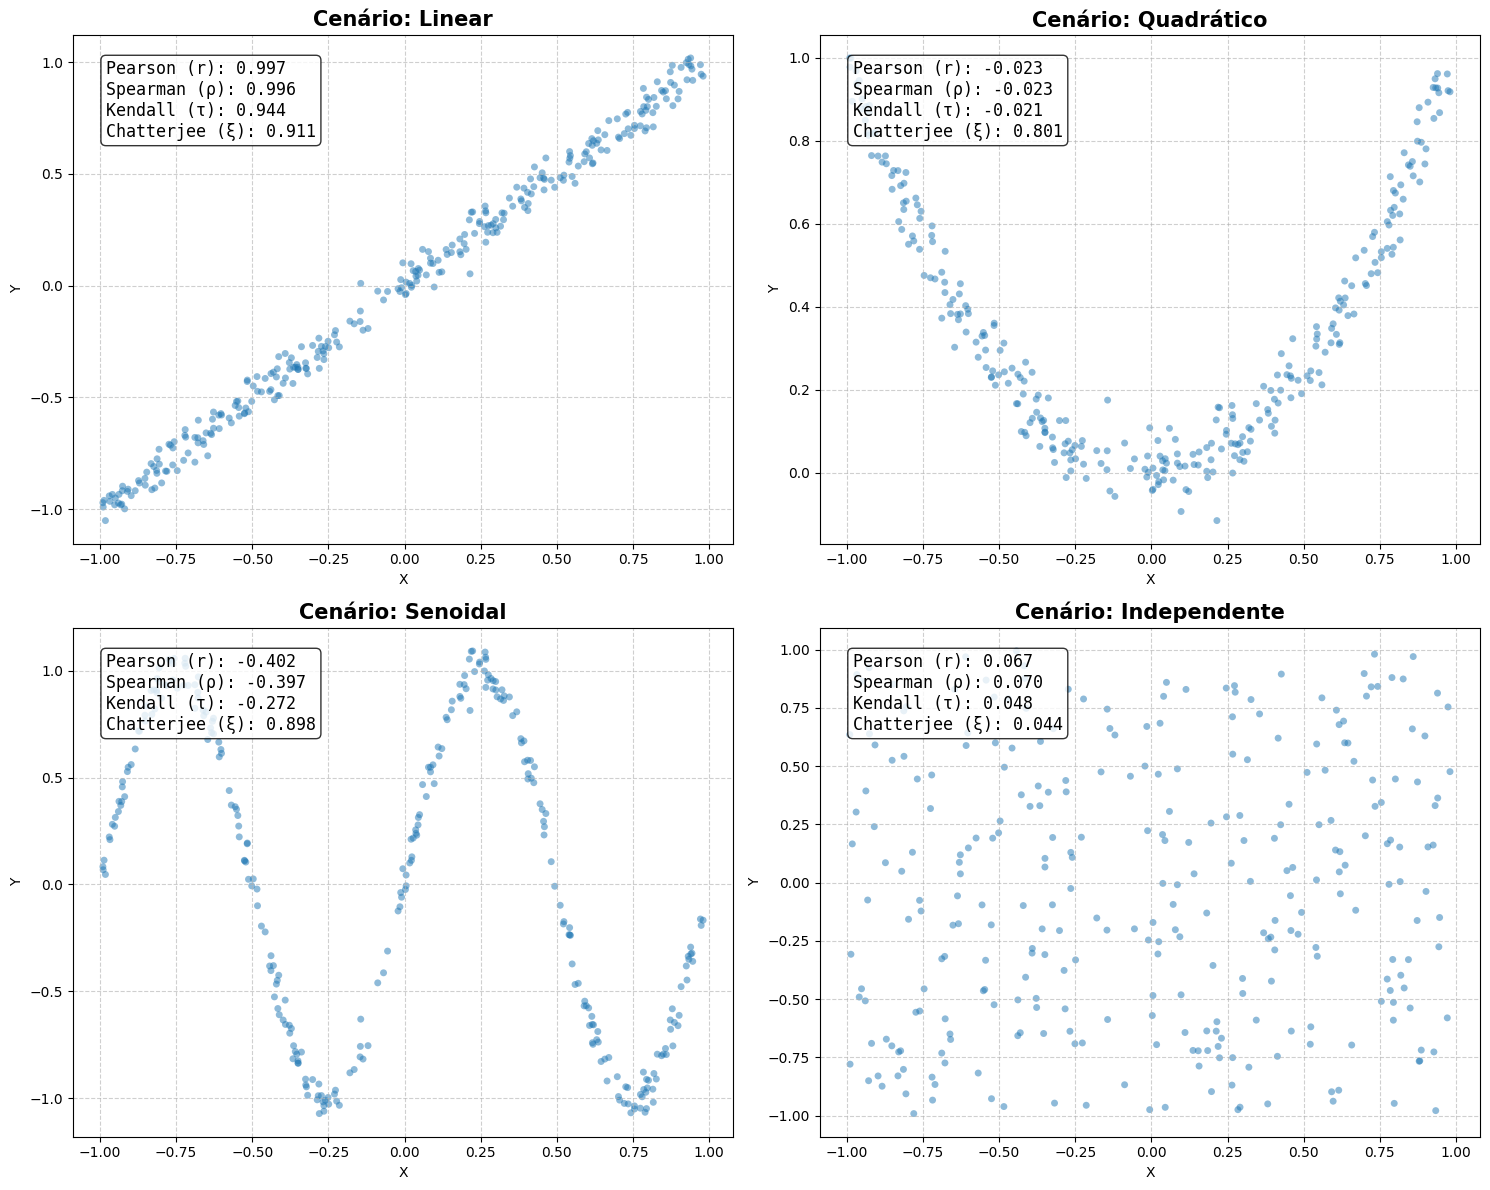

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau, chatterjeexi

# 1. Configuração e Geração de Dados Sintéticos
np.random.seed(42)
n = 300
x = np.random.uniform(-1, 1, n)
noise = np.random.normal(0, 0.05, n)

# Definição dos 4 Cenários (Linear, Quadrático, Senoidal e Independente)
datasets = [
    ("Linear", x + noise),
    ("Quadrático", x**2 + noise),
    ("Senoidal", np.sin(2 * np.pi * x) + noise),
    ("Independente", np.random.uniform(-1, 1, n))
]

# 2. Processamento e Visualização em Grade 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes_flat = axes.flatten()

for i, (name, y) in enumerate(datasets):
    # Cálculos das correlações usando SciPy
    r_p, _ = pearsonr(x, y)
    rho_s, _ = spearmanr(x, y)
    tau_k, _ = kendalltau(x, y)

    # Chatterjee xi via SciPy (retorna um objeto com .statistic e .pvalue)
    res_xi = chatterjeexi(x, y)
    xi = res_xi.statistic

    # Plotagem
    ax = axes_flat[i]
    ax.scatter(x, y, alpha=0.5, s=25, color='tab:blue', edgecolors='none')
    ax.set_title(f"Cenário: {name}", fontsize=15, fontweight='bold')

    # Formatação do texto de resultados
    stats_text = (
        f"Pearson (r): {r_p:.3f}\n"
        f"Spearman (ρ): {rho_s:.3f}\n"
        f"Kendall (τ): {tau_k:.3f}\n"
        f"Chatterjee (ξ): {xi:.3f}"
    )

    # Adição da caixa de texto com os índices
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            fontsize=12, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.tight_layout()
plt.show()